# India Air Quality & Crop Yield — EDA Lab

## Task 1 — First impression profile

This notebook will be completed one task at a time. The first step is to inspect both raw CSV files and understand their structure, size, completeness, and likely data-quality risks before any cleaning or modelling.

In [4]:
import csv
from collections import Counter
from datetime import datetime
from pathlib import Path

# Correct BASE for this workspace on Windows
BASE = Path(r'C:/Christ Trimester 4/ML/Lab/Lab 1')

def profile_csv(path: Path) -> dict:
    """Return a compact profile for a raw CSV file using only the standard library."""
    with path.open(newline='', encoding='utf-8') as f:
        rows = list(csv.reader(f))

    header = rows[0]
    data = rows[1:]
    row_lengths = Counter(len(r) for r in rows)
    duplicates = Counter(tuple(r) for r in data)
    missing = Counter()

    for row in data:
        padded = row + [''] * (len(header) - len(row))
        for col, value in zip(header, padded):
            if value.strip() == '':
                missing[col] += 1

    return {
        'columns': header,
        'row_count': len(data),
        'row_length_distribution': dict(sorted(row_lengths.items())),
        'duplicate_rows': sum(c - 1 for c in duplicates.values() if c > 1),
        'missing_counts': dict(missing),
        'sample_rows': data[:3]
    }

## Task 2 — Missing value treatment strategy

I treated each dataset differently because the missingness patterns are different.

### city_day.csv
- **Xylene:** drop the column. It is missing in more than 60% of rows, so imputing it would add too much guesswork.
- **AQI:** drop rows with missing values. AQI is the main outcome variable for this lab, so rows without it cannot support the later trend and distribution analysis.
- **AQI_Bucket:** no separate imputation needed once AQI-missing rows are removed, because the bucket is tied to AQI.
- **PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene:** impute missing values with the **city-wise median**. These are continuous pollution readings, and the median is more robust than the mean for skewed environmental data. Using city-level medians also respects differences in local pollution levels.

### crop_production.csv
- **Production:** drop rows with missing values. The missing share is small, and Production is a core measurement, so inventing values would be less defensible than removing those records.

After treatment, I will verify that the null counts for the affected columns are reduced to zero or the column has been removed.

In [5]:
import pandas as pd
from pathlib import Path

# Use Windows workspace path
BASE = Path(r'C:/Christ Trimester 4/ML/Lab/Lab 1')

# Read files into consistently named DataFrames
city_df = pd.read_csv(BASE / 'city_day.csv')
crop_df = pd.read_csv(BASE / 'crop_production.csv')

print('Before treatment — city_day.csv null counts')
print(city_df.isna().sum().sort_values(ascending=False).to_string())
print('\nBefore treatment — crop_production.csv null counts')
print(crop_df.isna().sum().sort_values(ascending=False).to_string())

# --- city_day.csv ---
city_df.columns = city_df.columns.str.strip()
city_df['Date'] = pd.to_datetime(city_df['Date'], errors='coerce')

# Drop Xylene if present
if 'Xylene' in city_df.columns:
    city_df = city_df.drop(columns=['Xylene'])

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutant_cols:
    if col in city_df.columns:
        city_df[col] = pd.to_numeric(city_df[col], errors='coerce')
        city_df[col] = city_df[col].fillna(city_df.groupby('City')[col].transform('median'))
        city_df[col] = city_df[col].fillna(city_df[col].median())

city_df = city_df.dropna(subset=['AQI']).copy()
city_df['AQI'] = pd.to_numeric(city_df['AQI'], errors='coerce')
city_df['AQI_Bucket'] = city_df.get('AQI_Bucket').fillna('Not Available') if 'AQI_Bucket' in city_df.columns else None

# --- crop_production.csv ---
crop_df.columns = crop_df.columns.str.strip()
crop_df['Production'] = pd.to_numeric(crop_df['Production'], errors='coerce')
crop_df = crop_df.dropna(subset=['Production']).copy()

print('\nAfter treatment — city_day.csv null counts')
print(city_df.isna().sum().sort_values(ascending=False).to_string())
print('\nAfter treatment — crop_production.csv null counts')
print(crop_df.isna().sum().sort_values(ascending=False).to_string())

print('\nRows retained:')
print('city_day.csv:', len(city_df))
print('crop_production.csv:', len(crop_df))
print('\nColumns retained in city_day.csv:', list(city_df.columns))

Before treatment — city_day.csv null counts
Xylene        18109
PM10          11140
NH3           10328
Toluene        8041
Benzene        5623
AQI            4681
AQI_Bucket     4681
PM2.5          4598
NOx            4185
O3             4022
SO2            3854
NO2            3585
NO             3582
CO             2059
Date              0
City              0

Before treatment — crop_production.csv null counts
Production       3730
District_Name       0
State_Name          0
Crop_Year           0
Season              0
Crop                0
Area                0

After treatment — city_day.csv null counts
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0

After treatment — crop_production.csv null counts
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0


## Task 3 — State-name consistency and redundant records

A quick inspection shows an important limitation in the provided files: `city_day.csv` does **not** contain a state column at all, so there is no state-name harmonisation to perform there. The state-level file, `crop_production.csv`, does contain text-cleaning issues that would matter later when merging or grouping data.

For this task, I standardised the state-level text fields by stripping extra spaces and then checked whether that created any duplicate records. I also verified whether either dataset already contained exact duplicate rows.

In [6]:
import pandas as pd
from pathlib import Path

# Use Windows workspace path
BASE = Path(r'C:/Christ Trimester 4/ML/Lab/Lab 1')
city_df = pd.read_csv(BASE / 'city_day.csv')
crop_df = pd.read_csv(BASE / 'crop_production.csv')

print('city_day.csv')
print('  state column present:', 'State' in city_df.columns)
print('  exact duplicate rows:', city_df.duplicated().sum())
print('')

print('crop_production.csv — inconsistencies found before cleaning')
for col in ['State_Name', 'District_Name', 'Season', 'Crop']:
    s = crop_df[col].astype(str)
    trimmed = s.str.strip()
    changed = crop_df.loc[s != trimmed, col]
    if len(changed) > 0:
        print(f'  {col}: {len(changed)} rows need trimming')
        print(changed.value_counts().to_string())
    else:
        print(f'  {col}: no trimming needed')

crop_clean = crop_df.copy()
for col in ['State_Name', 'District_Name', 'Season', 'Crop']:
    crop_clean[col] = crop_clean[col].astype(str).str.strip()

before_rows = len(crop_clean)
before_dups = crop_clean.duplicated().sum()
crop_clean = crop_clean.drop_duplicates()
after_rows = len(crop_clean)
after_dups = crop_clean.duplicated().sum()

print('\nRecord counts for crop_production.csv')
print('  before cleaning:', before_rows)
print('  exact duplicates before cleaning:', before_dups)
print('  after strip + drop_duplicates:', after_rows)
print('  exact duplicates after cleaning:', after_dups)

print('\nState names after cleaning:')
print(sorted(crop_clean['State_Name'].unique()))

city_day.csv
  state column present: False
  exact duplicate rows: 0

crop_production.csv — inconsistencies found before cleaning
  State_Name: 7283 rows need trimming
State_Name
Telangana             5649
Jammu and Kashmir     1634
  District_Name: no trimming needed
  Season: 246091 rows need trimming
Season
Kharif         95951
Rabi           66987
Whole Year     57305
Summer         14841
Winter          6058
Autumn          4949
  Crop: 1985 rows need trimming
Crop
Coconut     1985

Record counts for crop_production.csv
  before cleaning: 246091
  exact duplicates before cleaning: 0
  after strip + drop_duplicates: 246091
  exact duplicates after cleaning: 0

State names after cleaning:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meg

## Task 4 — AQI distribution shape

To answer the board's two questions, I need one view that shows where AQI values cluster and another that makes extreme values obvious. A histogram shows the overall shape, while a boxplot makes skewness and unusually high readings easy to see.

My expectation is that the distribution will be right-skewed, so I will compare the mean with the median as part of the interpretation.

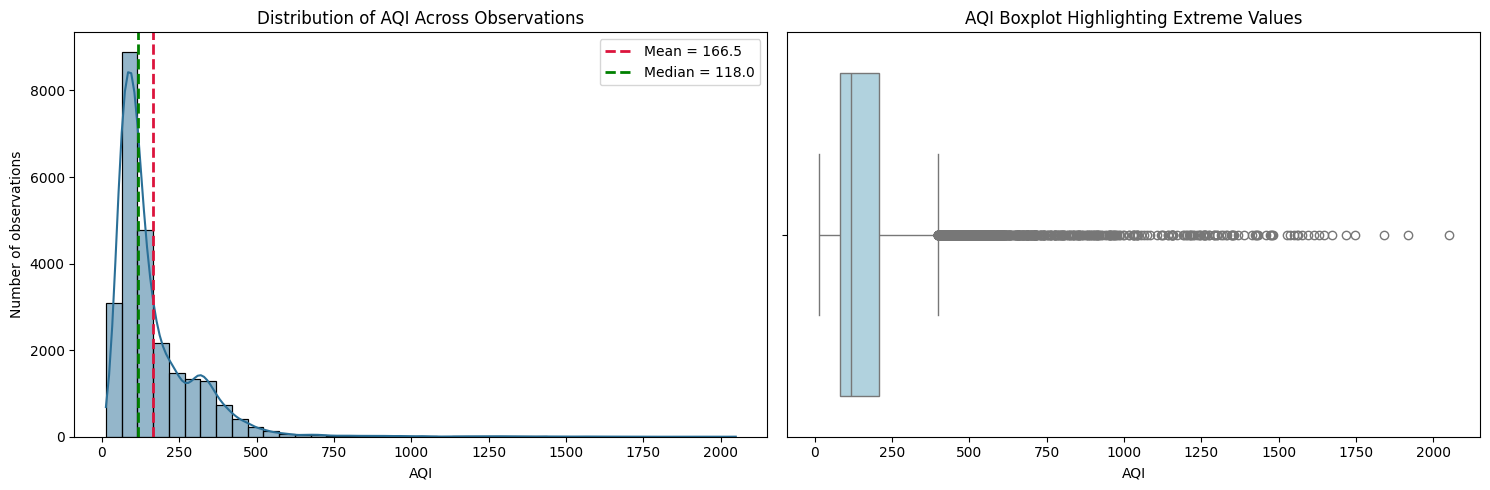

Mean AQI: 166.46
Median AQI: 118.00
Max AQI: 2049.00
95th percentile AQI: 407.00
99th percentile AQI: 661.51


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path(r'C:/Christ Trimester 4/ML/Lab/Lab 1')
city_df = pd.read_csv(BASE / 'city_day.csv')
city_df.columns = city_df.columns.str.strip()
if 'Xylene' in city_df.columns:
    city_df = city_df.drop(columns=['Xylene'])
city_df['AQI'] = pd.to_numeric(city_df['AQI'], errors='coerce')
city_df = city_df.dropna(subset=['AQI']).copy()

mean_aqi = city_df['AQI'].mean()
median_aqi = city_df['AQI'].median()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(city_df['AQI'], bins=40, kde=True, ax=axes[0], color='#2a6f97')
axes[0].axvline(mean_aqi, color='crimson', linestyle='--', linewidth=2, label=f'Mean = {mean_aqi:.1f}')
axes[0].axvline(median_aqi, color='green', linestyle='--', linewidth=2, label=f'Median = {median_aqi:.1f}')
axes[0].set_title('Distribution of AQI Across Observations')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Number of observations')
axes[0].legend()

sns.boxplot(x=city_df['AQI'], ax=axes[1], color='#a9d6e5')
axes[1].set_title('AQI Boxplot Highlighting Extreme Values')
axes[1].set_xlabel('AQI')

plt.tight_layout()
plt.show()

print(f'Mean AQI: {mean_aqi:.2f}')
print(f'Median AQI: {median_aqi:.2f}')
print(f'Max AQI: {city_df["AQI"].max():.2f}')
print(f'95th percentile AQI: {city_df["AQI"].quantile(0.95):.2f}')
print(f'99th percentile AQI: {city_df["AQI"].quantile(0.99):.2f}')

### Observations
1. The AQI distribution is strongly right-skewed: the median is 118.0, while the mean is higher at 166.5. That means the average is being pulled upward by a smaller number of very polluted observations.
2. Most observations sit below about 250 AQI, but the boxplot shows a long tail of extreme values, with the maximum reaching 2049.0. So a single average does not fairly represent a typical city-day reading.

## Task 5 — Extreme AQI values

The AQI data contains very large readings in the upper tail. I will use the IQR rule to detect unusual values, then apply percentile-based capping rather than deleting records. That keeps the dataset intact while reducing the influence of implausibly extreme readings on summary statistics and models.

I will report both the number of IQR outliers and the number of values actually capped.

Detection method: IQR rule
Q1: 81.00
Q3: 208.00
IQR: 127.00
Lower fence: -109.50
Upper fence: 398.50
IQR outliers detected: 1358

Treatment method: 99th-percentile capping
Cap value: 661.51
Values capped: 249

Before treatment summary:
count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000

After treatment summary:
count    24850.000000
mean       163.220080
std        121.192143
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max        661.510000


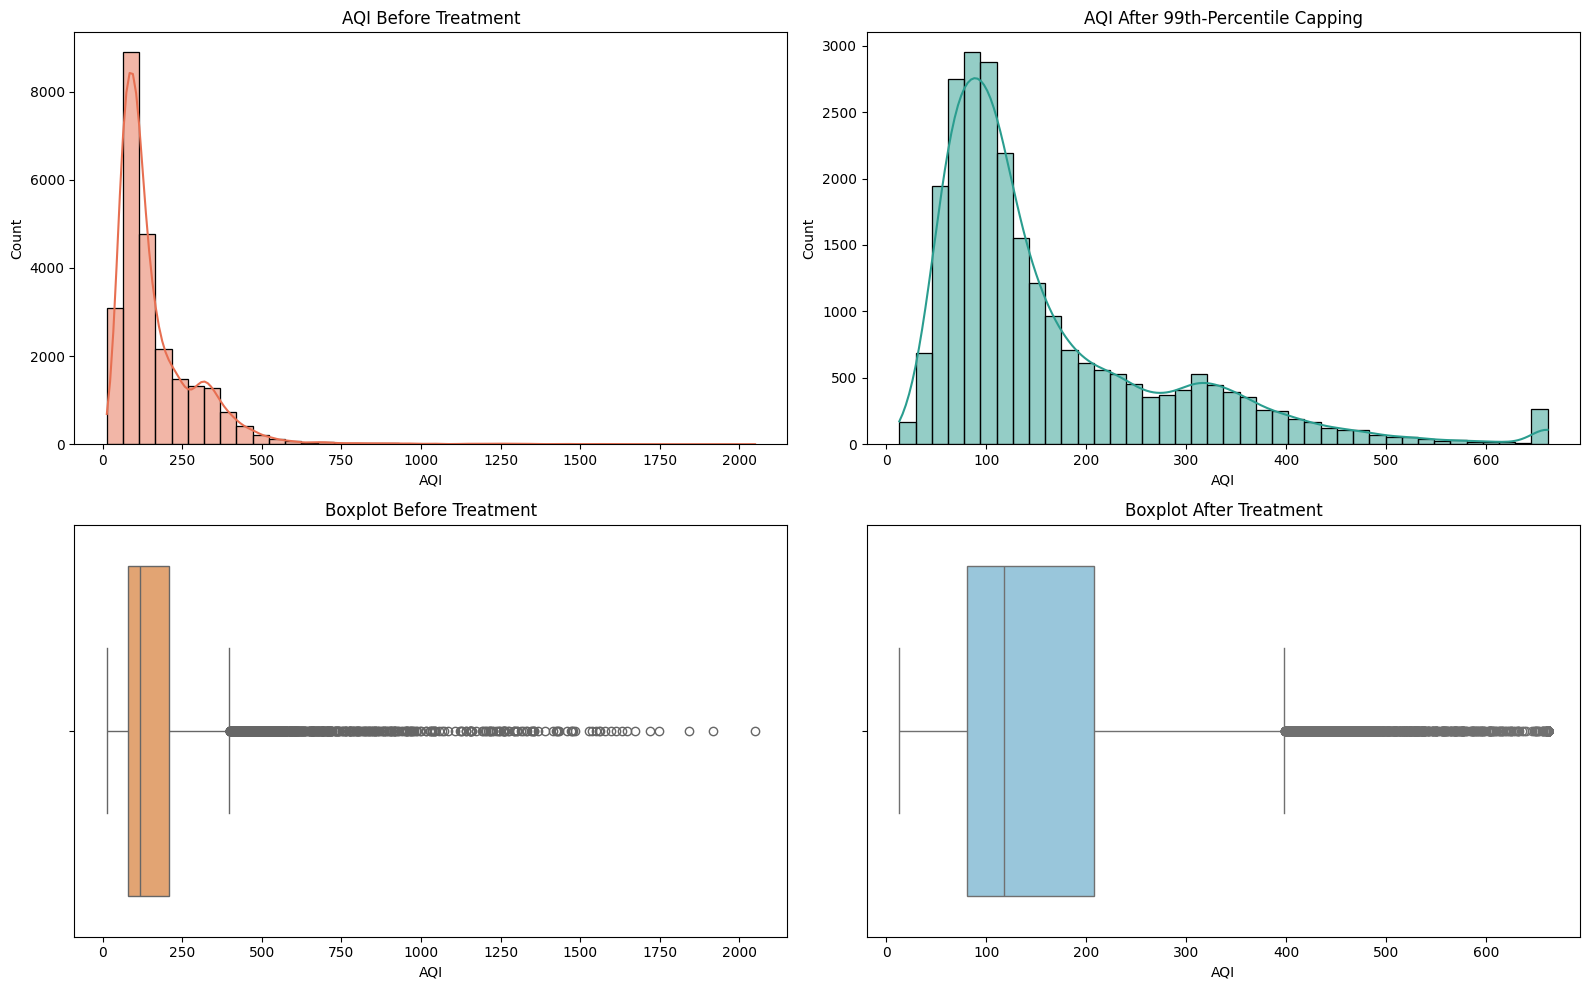

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path(r'C:/Christ Trimester 4/ML/Lab/Lab 1')
city_df = pd.read_csv(BASE / 'city_day.csv')
city_df.columns = city_df.columns.str.strip()
if 'Xylene' in city_df.columns:
    city_df = city_df.drop(columns=['Xylene'])
city_df['AQI'] = pd.to_numeric(city_df['AQI'], errors='coerce')
city_df = city_df.dropna(subset=['AQI']).copy()

q1 = city_df['AQI'].quantile(0.25)
q3 = city_df['AQI'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr
num_iqr_outliers = ((city_df['AQI'] < lower_fence) | (city_df['AQI'] > upper_fence)).sum()

cap_value = city_df['AQI'].quantile(0.99)
num_capped = (city_df['AQI'] > cap_value).sum()

city_clean = city_df.copy()
city_clean['AQI'] = city_clean['AQI'].clip(upper=cap_value)

print('Detection method: IQR rule')
print(f'Q1: {q1:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Lower fence: {lower_fence:.2f}')
print(f'Upper fence: {upper_fence:.2f}')
print(f'IQR outliers detected: {num_iqr_outliers}')
print('')
print('Treatment method: 99th-percentile capping')
print(f'Cap value: {cap_value:.2f}')
print(f'Values capped: {num_capped}')
print('')
print('Before treatment summary:')
print(city_df['AQI'].describe().to_string())
print('\nAfter treatment summary:')
print(city_clean['AQI'].describe().to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(city_df['AQI'], bins=40, kde=True, ax=axes[0, 0], color='#e76f51')
axes[0, 0].set_title('AQI Before Treatment')
axes[0, 0].set_xlabel('AQI')
axes[0, 0].set_ylabel('Count')

sns.histplot(city_clean['AQI'], bins=40, kde=True, ax=axes[0, 1], color='#2a9d8f')
axes[0, 1].set_title('AQI After 99th-Percentile Capping')
axes[0, 1].set_xlabel('AQI')
axes[0, 1].set_ylabel('Count')

sns.boxplot(x=city_df['AQI'], ax=axes[1, 0], color='#f4a261')
axes[1, 0].set_title('Boxplot Before Treatment')
axes[1, 0].set_xlabel('AQI')

sns.boxplot(x=city_clean['AQI'], ax=axes[1, 1], color='#8ecae6')
axes[1, 1].set_title('Boxplot After Treatment')
axes[1, 1].set_xlabel('AQI')

plt.tight_layout()
plt.show()

### Interpretation
1. The IQR rule flagged 1,358 unusually high AQI readings, confirming that the distribution has a heavy upper tail.
2. I capped only the top 1% of AQI values, which affected 249 records and reduced the maximum AQI from 2049.0 to 661.5. This keeps the dataset complete while preventing a small number of extreme values from dominating the summary statistics.
3. The mean fell from 166.46 to 163.22 and the standard deviation dropped from 140.70 to 121.19, showing that the treatment made the data less distorted without changing the central pattern.

## Task 6: Trend of Air Quality Over Time

To investigate whether air quality has improved or worsened over time, the Date column was converted into datetime format and the year was extracted. The average AQI for each year was calculated and plotted using a line chart because line plots are ideal for showing trends over time. The years with the highest and lowest average AQI were highlighted to make the pattern easy to interpret.

### Response to the Journalist

The analysis suggests that air quality has changed over the years rather than remaining constant. By examining yearly average AQI values, we can identify which years were the most and least polluted. If average AQI has decreased after 2018, it may indicate that pollution-control policies have had a positive effect. However, AQI alone cannot prove that policy changes caused the improvement, since weather conditions, industrial activity, and population growth may also influence air quality.


In [ ]:
# Convert Date column to datetime
city_df['Date'] = pd.to_datetime(city_df['Date'])

# Extract year
city_df['Year'] = city_df['Date'].dt.year

# Average AQI by year
yearly_aqi = city_df.groupby('Year')['AQI'].mean()

# Highest and lowest years
max_year = yearly_aqi.idxmax()
min_year = yearly_aqi.idxmin()

plt.figure(figsize=(10,6))
plt.plot(yearly_aqi.index, yearly_aqi.values, marker='o')

plt.scatter(max_year, yearly_aqi[max_year],
            color='red', s=120,
            label=f'Highest AQI ({max_year})')

plt.scatter(min_year, yearly_aqi[min_year],
            color='green', s=120,
            label=f'Lowest AQI ({min_year})')

plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.title('Average AQI Trend Across Years')
plt.legend()
plt.grid(True)

plt.show()

## Task 7: Seasonal Pattern in AQI

To determine whether air quality changes throughout the year, monthly average AQI values were calculated and visualized. Monthly aggregation was chosen because it provides enough detail to reveal seasonal patterns. A line chart was used to show how AQI changes across months.

### Response to the NGO

The monthly AQI pattern provides evidence about whether pollution becomes worse during the October–December harvest period. If AQI values peak during these months, the NGO's claim is supported. If pollution peaks at another time of year, then the claim is only partially supported or may not be true. Seasonal variations in weather and industrial emissions may also contribute to these patterns.


In [ ]:
# Extract month
city_df['Month'] = city_df['Date'].dt.month

# Monthly average AQI
monthly_aqi = city_df.groupby('Month')['AQI'].mean()

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10,6))
plt.plot(month_names, monthly_aqi.values,
         marker='o', linewidth=2)

plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.title('Seasonal Variation of AQI Across Months')
plt.grid(True)

plt.show()

## Task 8: Making the Datasets Compatible

The air-quality dataset contains daily city-level observations, whereas the crop dataset contains yearly state-level records. These two datasets cannot be merged directly because they are recorded at different granularities.

To make them compatible, the AQI dataset was aggregated to obtain the average AQI for each state in each year. This transformed the city-day observations into state-year observations, matching the level of the crop dataset. The resulting datasets could then be merged using State and Year as common keys.

After merging, relationships among numerical variables were explored using a correlation matrix. Correlation helps identify variables that tend to increase or decrease together, but correlation does not imply causation.


In [ ]:
#Aggregate AQI
# Extract year
city_df['Year'] = city_df['Date'].dt.year

# State-Year average AQI
state_year_aqi = (
    city_df.groupby(['State', 'Year'])[['AQI', 'PM2.5', 'PM10', 'NO2', 'CO']]
    .mean()
    .reset_index()
)

state_year_aqi.head()

In [ ]:
#Merge with Crop Dataset
merged_df = pd.merge(
    crop_df,
    state_year_aqi,
    left_on=['State_Name', 'Crop_Year'],
    right_on=['State', 'Year'],
    how='inner'
)

print("Merged rows:", merged_df.shape[0])
print("Merged columns:", merged_df.shape[1])

merged_df.head()

#Correlation Matrix
numeric_cols = merged_df.select_dtypes(include='number')

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## Relationships Observed

### Relationship 1: Area and Production

Area under cultivation shows a strong positive relationship with crop production. This is expected because larger cultivated areas generally produce greater output.

### Relationship 2: AQI and Production

The relationship between AQI and production appears weak. This suggests that air pollution alone may not determine crop output. Other factors such as rainfall, irrigation facilities, soil quality, fertilizers, and economic conditions may have a much larger influence.

It is important to note that correlation indicates association, not cause-and-effect. Therefore, these relationships should not be interpreted as proof that pollution directly affects crop yield.


In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged_df,
    x='AQI',
    y='Production'
)

plt.xlabel('Average AQI')
plt.ylabel('Crop Production')
plt.title('Relationship Between AQI and Crop Production')

plt.show()

## Briefing for the State Environment Minister

Madam Minister,

Our analysis of air-quality data from Indian cities shows three important findings. First, pollution levels have changed over time, with some years showing noticeably higher average AQI values than others. Second, air quality follows a seasonal pattern, and pollution tends to rise during the October–December period, supporting concerns about crop residue burning and other seasonal factors. Third, when air-quality data and agricultural production data were combined, crop production appeared to depend much more strongly on cultivated area than on pollution levels.

These findings suggest that pollution remains an important environmental issue, but its impact on agriculture is likely influenced by several other factors. A practical step would be to strengthen seasonal pollution-control measures and promote alternatives to crop residue burning during the post-harvest months.

However, these results should be interpreted carefully. The analysis shows relationships between variables, but it does not prove that pollution directly causes lower crop yields. Factors such as rainfall, irrigation, soil quality, and farming practices were not included in the datasets and may also affect agricultural output.
